# <font color='blue'> 기계학습을 이용한 해외제조가공업소의 현지실사 프로세스 효율화 방안
<img src = 'https://images.unsplash.com/photo-1501290741922-b56c0d0884af?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Mnx8cmVzZWFyY2h8ZW58MHx8MHx8&auto=format&fit=crop&w=500&q=60'>

In [51]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
plt.rcParams['axes.unicode_minus'] = False

In [52]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

## 현지실사과(식약처) 현지실사 계획 수입 방법(계획실사 : 년간 1회)
### 1. 과거 5년동안 수입민원정보를 참고하고 
### 2. 최근 1년간의 수입민원정보에서 업체별 통계(부적합률, 수입빈도 및 물량 등)와
### 3. 수거검사시 적발된 제품의 업체정보를 파악하여 매년 9~10월에 차년도 현지실사계획 수립

### 기획 현지실사는 민원(Complaint) 등으로 수행(중국 김치공장 전수조사)

# 수입식품안전관리 특별법 ( 약칭: 수입식품법 )
수입식품안전관리 특별법
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=234855#0000
   
수입식품안전관리 특별법 시행령
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=240329#0000

수입식품안전관리 특별법 시행규칙
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220701&lsiSeq=233697#0000
   ** 수입민원신고서([별지 제25호서식] 수입식품등의 수입신고서)

## 해외제조업소 등록신청서
### 해외제조가공업소 기본 속성 정보
법 제5조(해외제조업소 등록) ① 수입식품등을 국내로 수입하려는 자 또는 해외제조업소의 설치ㆍ운영자(이하 “수입자등”이라 한다)는 해당 해외제조업소의 명칭, 소재지 및 생산 품목 등 총리령으로 정하는 사항을 제20조에 따른 수입신고 전까지 식품의약품안전처장에게 등록하여야 한다.

<img src='https://www.law.go.kr/LSW/flDownload.do?flSeq=113540777'>

### 해외제조업소 점검표 (별표2 삭제)
법 제6조(해외제조업소의 현지실사) ① 식품의약품안전처장은 다음 각 호의 어느 하나에 해당하는 경우에는 수출국 정부 또는 해외제조업소와 사전에 협의를 거쳐 해외제조업소에 대하여 현지실사를 할 수 있다.

In [53]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        
    return tf

# 1. 데이터 확보
## 데이터 전처리 완료

In [54]:
import glob
path = r'D:\smart food\현지실사\2022_2_현지실사\working'
file_list = glob.glob(path + '/*.*')
file_list

['D:\\smart food\\현지실사\\2022_2_현지실사\\working\\11. 대장_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\12. 대장_변경내역_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\13. 관리시스템_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\14. 품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\15. 식품_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\16. 중단품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\17. 중단(수입)_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\18. 영업종류_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\22. 수입민원_업소별_품목특성_gzip',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\33. WorldBank_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\41. 품목코드_특성_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\51. 현지실사결과_gzip.pkl']

In [55]:
'''
for file in file_list:
    print('파일이름 : ', file)
    pd.read_pickle(file, compression='gzip').head(2)
    print('*'*200)
'''''

"\nfor file in file_list:\n    print('파일이름 : ', file)\n    pd.read_pickle(file, compression='gzip').head(2)\n    print('*'*200)\n"

## MCA 2차원 축소 시각화

In [56]:
import prince

def mca_visulaization(df):
    input_X = df.copy()
    mca = prince.MCA(n_components=2).fit(input_X)
    ax = mca.plot_coordinates(X = input_X, figsize=(20, 6), show_column_labels=True)
    ax.set_title("Correspondence analysis", fontsize = 18)

In [57]:
from sklearn.tree import DecisionTreeClassifier

def visual_predict_tree(data):
    X = data.drop(['target'], axis=1)
    y = data.target
    cassifier = DecisionTreeClassifier()
    cassifier.fit(X, y)
    plt.figure(figsize=(25,8))
    ax = plot_tree(cassifier, filled=True)
    #plt.legend(loc='lower right', borderpad=0, handletextpad=0)

## 1.1. CO_IFD_OVSMNFST_REGSTR_M 
수입식품 해외제조업소 대장
국가, 업소명, 대표자명, 주소, 전화번호, 이메일, 팩스번호, 인증, E42_취소_중단_코드 등 16개 특성변수

## 전체데이터가 아닌 현지실사 대상 데이터만 추출

In [58]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
df = pd.read_pickle(path + '/data_01_대장.pkl').set_index('해외제조업소_코드').drop('A02_국가코드', axis=1)
df.head()
df.shape

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False


(1689, 15)

## 의사결정트리로 예측하기

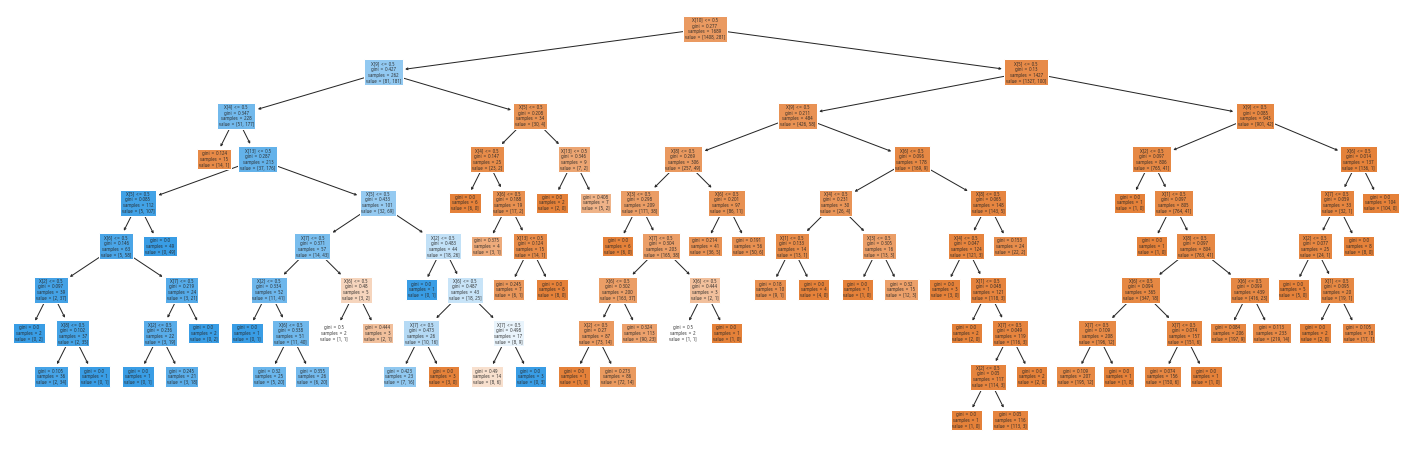

In [59]:
visual_predict_tree(df)

In [60]:
'''# A02_국가코드 컬럼에 31개의 null값이 존재
df = pd.read_pickle(file_list[0], compression='gzip').drop('A02_국가코드', axis=1)
df
df.isnull().sum().sum()
'''

"# A02_국가코드 컬럼에 31개의 null값이 존재\ndf = pd.read_pickle(file_list[0], compression='gzip').drop('A02_국가코드', axis=1)\ndf\ndf.isnull().sum().sum()\n"

## 1.2. CO_IFD_OVSMNFST_REGSTR_CHNG_H 
수입식품 해외제조업소 대장 변경내역
신규변경과 갱신여부 등 36개 특성변수 

In [61]:
tf = pd.read_pickle(file_list[1], compression='gzip')
tf.isnull().sum().sum()
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

0

,해외제조업소_코드,new_01,new_02,new_03,new_04,new_05,new_06,new_07,new_08,new_09,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
0,014566,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,017426,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,017620,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,021823,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,023215,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18235,ZA000001913,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18236,ZA000001920,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
18237,ZA000001928,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18238,ZA000001948,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


### 10개의 변수만 가지고 MCA 그래프 시각화

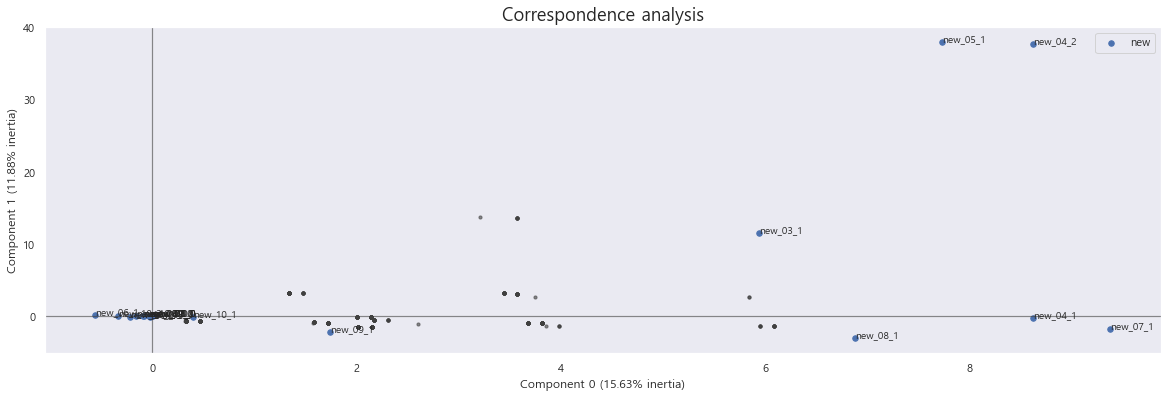

In [62]:
mca_visulaization(tf.set_index('해외제조업소_코드').iloc[:, 0:10].astype('category'))

In [63]:
df = pd.merge(df, tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
df

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [64]:
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


DecisionTreeClassifier()

<Figure size 1800x576 with 0 Axes>

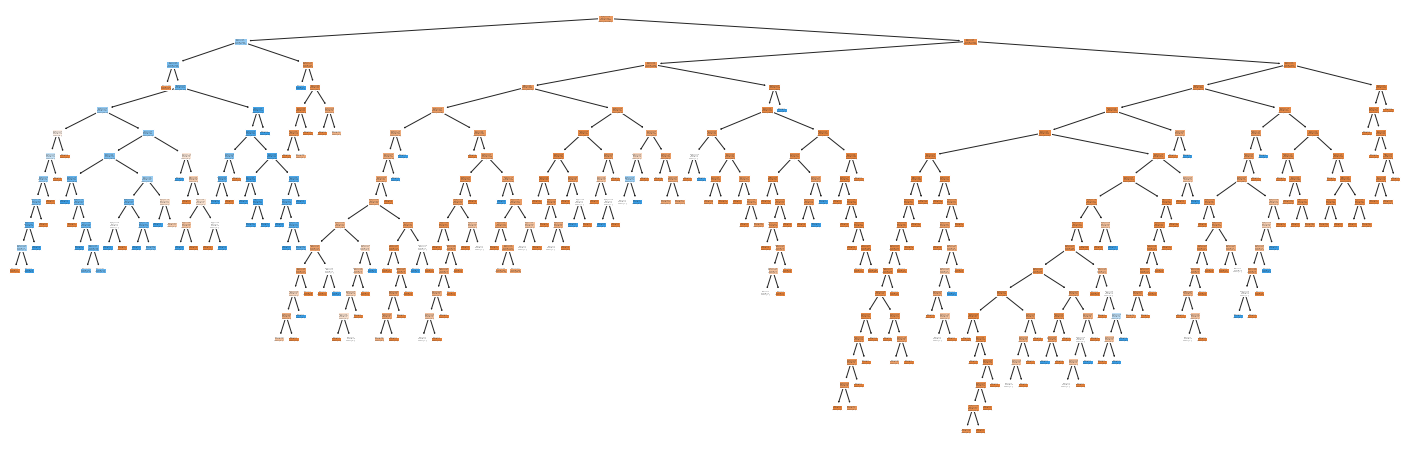

In [65]:
y = df.target
dt = DecisionTreeClassifier()
dt.fit(X, y)
plt.figure(figsize=(25,8))
ax = plot_tree(dt, filled=True)

In [66]:
from sklearn.model_selection import cross_val_score, cross_validate
cross_val_score(dt, X, y, cv=5)
pd.DataFrame(cross_validate(dt, X, y, 
               scoring=['accuracy', 'roc_auc', 'average_precision', 'recall'], 
               return_train_score=True))

array([0.88461538, 0.8964497 , 0.88757396, 0.84615385, 0.88130564])

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_average_precision,train_average_precision,test_recall,train_recall
0,0.008975,0.009974,0.881657,0.951147,0.813956,0.971109,0.490480,0.902888,0.607143,0.746667
1,0.010970,0.009005,0.887574,0.943005,0.792901,0.969564,0.472468,0.892780,0.625000,0.706667
2,0.008948,0.007979,0.878698,0.948187,0.798791,0.969455,0.459248,0.892837,0.553571,0.737778
3,0.007978,0.007979,0.852071,0.943005,0.740057,0.966750,0.386550,0.887071,0.649123,0.705357
4,0.008976,0.007978,0.884273,0.946746,0.789432,0.967662,0.498871,0.892393,0.517857,0.733333


### MCA를 이용한 차원축소

In [67]:
input_X = tf.set_index('해외제조업소_코드').astype('category').copy()
mca = prince.MCA(n_components=2).fit(input_X)
mca.transform(input_X)

,0,1
014566,0.045485,-0.125312
017426,-0.000472,-0.177489
017620,-0.000472,-0.177489
021823,0.082452,-0.063890
023215,-0.107961,-0.094949
...,...,...
ZA000001913,-0.152956,-0.105594
ZA000001920,-0.080794,-0.149426
ZA000001928,-0.143672,-0.184503
ZA000001948,-0.101272,-0.032475


## 1.3. CO_IFD_OVSMNFST_MNGSYS_D 
수입식품 해외제조업소 관리시스템
식품안전관리시스템 구분코드 3개 특성변수


In [68]:
tf = pd.read_pickle(file_list[2], compression='gzip')
tf.isnull().sum().sum()
tf

0

E39_식품안전관리시스템_구분_코드,인증_1,인증_2,인증_3
해외제조업소_코드,,,
027304,True,False,False
029333,True,True,False
039292,True,False,True
AE000000002,False,False,True
AE000000003,True,False,True
...,...,...,...
ZA000001951,False,False,True
ZA000001959,False,False,True
ZA000001970,False,False,True


In [69]:
df.reset_index(inplace=True)

In [70]:
df = pd.merge(df, tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


In [71]:
cross_val_score(dt, X, y, cv=5)

df

array([0.85798817, 0.87869822, 0.87278107, 0.84023669, 0.884273  ])

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


## 1.4. CO_IFD_OVSMNFST_ITM_D 
수입식품 해외제조업소 품목
기능성원료, 수입식품생성, 유통관리대상, 수산부산물, 신고구분 및 품목유형 등 22개 특성변수


In [72]:
tf = pd.read_pickle(file_list[3], compression='gzip')
tf.isnull().sum().sum()
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

0

,해외제조업소_코드,기능성원료,수입식품생성,유통관리대상,수산부산물,ANIMALMDCN,SEPARUSE,MIXTR,신고구분_1,신고구분_2,...,신고구분_6,신고구분_7,신고구분_8,품목_A,품목_B,품목_C,품목_D,품목_E,품목_F,품목_Z
0,AE000000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,AE000000003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,AE000000006,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,AE000000008,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,AE000000111,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58187,ZA000001976,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
58188,ZM000000001,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
58189,ZM000000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
58190,ZM000000003,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [73]:
df

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


In [74]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,신고구분_6,신고구분_7,신고구분_8,품목_A,품목_B,품목_C,품목_D,품목_E,품목_F,품목_Z
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [76]:
cross_val_score(dt, X, y, cv=5)

array([0.84319527, 0.88461538, 0.89940828, 0.73076923, 0.87833828])

## 1.5. CO_IFD_OVSMNFST_FOOD_D 
수입식품 해외제조업소 식품
식품과 수산물 코드로 9개 특성변수(년도별)


In [77]:
tf = pd.read_pickle(file_list[4], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
해외제조업소_코드,연도,,,,,,,,,
AE000000002,2020,False,True,False,False,False,False,False,False,False
AE000000003,2020,False,True,False,False,False,False,False,False,False
AE000000006,2020,False,True,False,False,True,False,False,False,False
AE000000007,2020,False,False,False,False,True,False,False,False,False
AE000000008,2020,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
ZZ000000028,2020,False,False,False,True,False,False,False,False,False
ZZ000000029,2020,False,False,False,True,False,False,False,False,False
ZZ000000030,2020,False,False,False,True,False,False,False,False,False


In [78]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

,해외제조업소_코드,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
0,AE000000002,0,1,0,0,0,0,0,0,0
1,AE000000003,0,1,0,0,0,0,0,0,0
2,AE000000006,0,1,0,0,1,0,0,0,0
3,AE000000007,0,0,0,0,1,0,0,0,0
4,AE000000008,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
115949,ZZ000000028,0,0,0,1,0,0,0,0,0
115950,ZZ000000029,0,0,0,1,0,0,0,0,0
115951,ZZ000000030,0,0,0,1,0,0,0,0,0
115952,ZZ000000031,0,0,0,1,0,0,0,0,0


In [80]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,품목_Z,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


array([0.86390533, 0.83727811, 0.85502959, 0.72781065, 0.87240356])

## 1.6. CO_IFD_OVSMNFST_DSCNTC_ITM_D 
수입식품 해외제조업소 중단 품목
중단해제, 중단중 2개 특성변수(년도별)

In [81]:
tf = pd.read_pickle(file_list[5], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,중단해제,중단중
해외제조업소_코드,연도,,
AU000000627,2016,6,0
AU000000693,2021,11,0
BD000000005,2016,6,0
BD000000116,2016,6,0
BD000000134,2016,6,0
...,...,...,...
VN000008897,2016,0,6
VN000008898,2016,0,6
VN000008900,2016,0,6


In [82]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf
tf.describe()

,해외제조업소_코드,중단해제,중단중
0,AU000000627,6,0
1,AU000000693,11,0
2,BD000000005,6,0
3,BD000000116,6,0
4,BD000000134,6,0
...,...,...,...
525,VN000008906,0,6
526,VN000008907,0,6
527,VN000009030,11,0
528,VN000009249,11,0


,중단해제,중단중
count,530.00000,530.000000
mean,3.69434,1.711321
std,2.48948,13.426326
min,0.00000,0.000000
25%,3.00000,0.000000
50%,3.00000,0.000000
75%,6.00000,0.000000
max,11.00000,240.000000


<AxesSubplot:>

0      459
6       26
1       24
11       5
4        3
2        3
7        2
43       1
68       1
17       1
47       1
23       1
39       1
163      1
240      1
Name: 중단중, dtype: int64

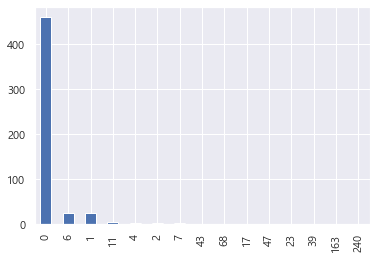

In [83]:
tf['중단중'].value_counts().plot(kind='bar')
tf['중단중'].value_counts()

In [84]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3,중단해제,중단중
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


array([0.86686391, 0.85798817, 0.87278107, 0.79881657, 0.88724036])

## 1.7. CO_IFD_OVSMNFST_DSCNTC_D 
수입식품 해외제조업소 중단
중단코드 4개 특성변수(년도별)

## 1.8. CO_IFD_OVSMNFST_BZKND_D 
수입식품 해외제조업소 영업종류
영업구분과 ARG 구분으로 11개 특성변수


In [85]:
tf = pd.read_pickle(file_list[7], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,연도,,,,,,,,,,,
014566,2020,True,False,False,False,True,False,False,False,False,False,False
015002,2020,False,False,False,False,True,False,False,False,False,False,False
016235,2020,False,False,False,False,True,False,False,False,False,False,False
016248,2020,True,False,False,False,False,False,False,False,False,False,False
017426,2020,True,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
ZM000000001,2021,False,False,True,False,False,False,False,False,False,False,False
ZM000000002,2021,True,False,False,False,False,False,False,False,False,False,False
ZM000000003,2020,False,False,True,False,False,False,False,False,False,False,False


In [86]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf
tf.describe()

,해외제조업소_코드,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
0,014566,1,0,0,0,1,0,0,0,0,0,0
1,015002,0,0,0,0,1,0,0,0,0,0,0
2,016235,0,0,0,0,1,0,0,0,0,0,0
3,016248,1,0,0,0,0,0,0,0,0,0,0
4,017426,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
89085,ZM000000001,0,0,1,0,0,0,0,0,0,0,0
89086,ZM000000002,1,0,0,0,0,0,0,0,0,0,0
89087,ZM000000003,0,0,1,0,0,0,0,0,0,0,0
89088,ZM000000004,1,0,0,0,0,0,0,0,0,0,0


,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
count,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000
mean,0.554956,0.293636,0.170592,0.042249,0.101010,0.000382,0.001369,0.000382,0.000763,0.000112,0.000045
std,0.496973,0.455430,0.376154,0.201159,0.301344,0.019532,0.036980,0.019532,0.027617,0.010594,0.006701
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [87]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


array([0.87278107, 0.84911243, 0.86686391, 0.78698225, 0.884273  ])

# 2. 훈련과 검증데이터

## 2.1. 현지실사 완료 데이터로 미방문 업소 예측
### 2.1.1. 현지실사가 완료된 데이터

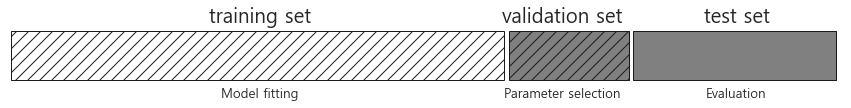

In [89]:
#! pip install mglearn
import mglearn
mglearn.plots.plot_threefold_split()

In [88]:
X
y

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


해외제조업소_코드
CN000095375    False
CN000010833    False
VN000000420    False
JP000002818    False
TH000001271    False
               ...  
DE000000001    False
US000000418    False
US000000318    False
PH000000007    False
PH000000010    False
Name: target, Length: 1689, dtype: bool

In [90]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y,  random_state=12)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, stratify=y_train, random_state=12)

print('훈련데이터(traing set) Data(X,y)크기와 부적합율')
[X_train.shape, y_train.shape]
(y_train.sum()/len(y_train)).round(4)
print('검증데이터(validation set) Data(X,y)크기와 부적합율')
[X_val.shape, y_val.shape]
(y_val.sum()/len(y_val)).round(4)
print('테스트데이터(test set) Data(X,y)크기와 부적합율')
[X_test.shape, y_test.shape]
(y_test.sum()/len(y_test)).round(4)

훈련데이터(traing set) Data(X,y)크기와 부적합율


[(1080, 97), (1080,)]

0.1667

검증데이터(validation set) Data(X,y)크기와 부적합율


[(271, 97), (271,)]

0.1661

테스트데이터(test set) Data(X,y)크기와 부적합율


[(338, 97), (338,)]

0.1657

## 2.1.2. Cross validation and Hyperparameter tuninig

In [94]:
from sklearn import ensemble 
from sklearn.linear_model import LogisticRegression

classifiers = {}
classifiers.update({'Logistic regression': LogisticRegression()})
classifiers.update({'Random Forest': ensemble.RandomForestClassifier()})
classifiers.update({'Gradient Boosting': ensemble.GradientBoostingClassifier()})
classifiers

{'Logistic regression': LogisticRegression(),
 'Random Forest': RandomForestClassifier(),
 'Gradient Boosting': GradientBoostingClassifier()}

In [91]:
parameters = {}

parameters.update({'Logistic regression': 
{
'classifier__C': np.logspace(-4, 4, 20), 
'classifier__class_weight': [None, 'balanced'],
'classifier__penalty': ['l1', 'l2']    
}})

parameters.update({'Random Forest': 
{ 
'classifier__n_estimators': [50, 100, 150, 200, 250, 300],
'classifier__class_weight': [None, 'balanced'],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__max_depth' : [int(x) for x in np.linspace(3, 50, 20)],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__criterion' :['gini', 'entropy'],
'classifier__n_jobs': [-1]
}})

parameters.update({'Gradient Boosting': 
{ 
'classifier__learning_rate':[0.15,0.1,0.05,0.01,0.005,0.001], 
'classifier__n_estimators': [200],
'classifier__max_depth': [2,3,4,5,6],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__subsample': [0.8, 0.9, 1]
}})


In [92]:
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, plot_roc_curve, plot_confusion_matrix, classification_report, balanced_accuracy_score
from sklearn import metrics

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from joblib import dump, load

In [96]:
X.dtypes

업소명      category
대표자성명    category
주소       category
전화번호     category
이메일      category
           ...   
ARG_2    category
ARG_3    category
SEA_4    category
SEA_5    category
SEA_6    category
Length: 97, dtype: object

In [97]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features  = X.select_dtypes(include=['category']).columns
categorical_features

Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', 'new_01', 'new_02', 'new_03', 'new_04', 'new_05',
       'new_06', 'new_07', 'new_08', 'new_09', 'new_10', 'new_11', 'new_12',
       'new_13', 'new_14', 'new_15', 'new_16', 'new_17', 'new_42', 'modify_01',
       'modify_02', 'modify_03', 'modify_04', 'modify_05', 'modify_06',
       'modify_07', 'modify_08', 'modify_09', 'modify_10', 'modify_11',
       'modify_12', 'modify_13', 'modify_14', 'modify_15', 'modify_16',
       'modify_17', 'modify_42', '인증_1', '인증_2', '인증_3', '기능성원료', '수입식품생성',
       '유통관리대상', '수산부산물', 'ANIMALMDCN', 'SEPARUSE', 'MIXTR', '신고구분_1',
       '신고구분_2', '신고구분_3', '신고구분_4', '신고구분_5', '신고구분_6', '신고구분_7', '신고구분_8',
       '품목_A', '품목_B', '품목_C', '품목_D', '품목_E', '품목_F', '품목_Z', '식품코드_1',
       '식품코드_2', '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2',
       '수산물코드_3', '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4',
       '영업구분_5', 'ARG

In [98]:
results = {}
kf = KFold(n_splits=5)

for classifier_label, classifier in classifiers.items():
    
    # 1. 입력변수의 유형에 따라 데이터 전처리를 tranformers로 저장
    numeric_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())])
    categorical_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('woe_catencoder', ce.woe.WOEEncoder())])
    
    # 2. tranformers를 ColumnTransformer로 연결
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])    
    
    # 3. 데이터전처리를 파이프라인으로 연결
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)])
    
    # 4. 랜덤그리드 서치로 파이프라인(데이터존처리와 알고리즘), 하이퍼파라미터, 교차검증, 최적화 metric) 연결
    param_grid = parameters[classifier_label]
    grid = RandomizedSearchCV(pipeline, param_grid, cv = kf,  n_jobs= -1,
                          n_iter = 30,
                          verbose=1,
                          scoring = 'recall_macro')  # recall_macro
    
    # 5. 훈련데이터로 최적 모델 찾고 저장하기
    grid.fit(X_train, y_train) # Fitting
    print('최적 모델의 훈련데이터 score: {:.3f}'.format(grid.best_score_))
    print('최적모델의 검증데이터 score: {:.3f}'.format(grid.score(X_val, y_val)))
    print('최적 모델 parameter: {}'.format(grid.best_params_))
    
    dump(grid.best_estimator_, path + '/' + classifier_label + '.joblib')
    
    # 6. 훈련과정 보기
    pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()
    
    # 6. 훈련데이터로 재현율로 최적화된 모형으로 검증데이터에 적용 
    y_pred = grid.best_estimator_.predict(X_val)
    y_proba = grid.best_estimator_.predict_proba(X_val)
    y_score = y_proba[:,1]
    
    print('*'*50); print('Classifier name : ', classifier_label )
    print(classification_report(y_val, y_pred))
    
    result = {#'Classifier': classifier_label,
              'Best Parameters': grid.best_params_,
              'Recall_macro': metrics.recall_score(y_val, y_pred, average='macro'),
              'AUROC' : metrics.roc_auc_score(y_val, y_score),
              'Average PR': metrics.average_precision_score(y_val, y_score),
              'F1-score': metrics.f1_score(y_val, y_pred),
              'Accuracy': metrics.accuracy_score(y_val, y_pred),
              'Log_loss': metrics.log_loss(y_val, y_proba),
              'Brier_scor': metrics.brier_score_loss(y_val, y_proba[:,1]),
              'MC': metrics.matthews_corrcoef(y_val, y_pred),
              'Ballanced Accuracy' : balanced_accuracy_score(y_val, y_pred)
             }
    results.update({classifier_label: result})

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',...
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__penalty': ['l1', 'l2']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.824
최적모델의 검증데이터 score: 0.798
최적 모델 parameter: {'classifier__penalty': 'l2', 'classifier__class_weight': 'balanced', 'classifier__C': 0.03359818286283781}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Logistic regression.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__penalty,param_classifier__class_weight,param_classifier__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,2.479185,0.107637,0.291436,0.013080,l2,balanced,0.033598,"{'classifier__penalty': 'l2', 'classifier__cla...",0.752565,0.818606,0.854072,0.852092,0.840568,0.823581,0.037681,1
29,1.987489,0.143314,0.166963,0.049111,l2,balanced,0.088587,"{'classifier__penalty': 'l2', 'classifier__cla...",0.752565,0.819373,0.856820,0.838279,0.829519,0.819311,0.035569,2
2,2.882469,0.492891,0.353056,0.054051,l2,balanced,0.012743,"{'classifier__penalty': 'l2', 'classifier__cla...",0.752565,0.806411,0.856820,0.837806,0.840568,0.818834,0.036935,3
28,2.279902,0.153336,0.242152,0.030406,l2,None,4.281332,"{'classifier__penalty': 'l2', 'classifier__cla...",0.746093,0.808502,0.875081,0.805998,0.771902,0.801515,0.043427,4
27,2.333957,0.050471,0.288628,0.010791,l2,None,11.288379,"{'classifier__penalty': 'l2', 'classifier__cla...",0.746093,0.808502,0.872334,0.800474,0.769140,0.799308,0.042803,5


**************************************************
Classifier name :  Logistic regression
              precision    recall  f1-score   support

       False       0.93      0.93      0.93       226
        True       0.65      0.67      0.66        45

    accuracy                           0.89       271
   macro avg       0.79      0.80      0.80       271
weighted avg       0.89      0.89      0.89       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',...
                                        'classifier__max_depth': [3, 5, 7, 10,
                                                                  12, 15, 17,
                                                                  20, 22, 25,
                                                                  27, 30, 32,
                                                                  35, 37, 40,
                                                                  42, 45, 47,
                                                                  50],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [50, 100,
                                                                     150, 200,
                                                                     250, 300],
                                        'classifier__n_jobs': [-1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.823
최적모델의 검증데이터 score: 0.809
최적 모델 parameter: {'classifier__n_jobs': -1, 'classifier__n_estimators': 100, 'classifier__min_samples_split': 0.01, 'classifier__min_samples_leaf': 0.01, 'classifier__max_features': 'auto', 'classifier__max_depth': 5, 'classifier__criterion': 'entropy', 'classifier__class_weight': 'balanced'}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Random Forest.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__n_jobs,param_classifier__n_estimators,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__max_depth,...,param_classifier__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,2.555365,0.014932,0.339892,0.046947,-1,100,0.01,0.01,auto,5,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.747040,0.833659,0.856820,0.838279,0.838279,0.822815,0.038714,1
7,2.627173,0.141853,0.376594,0.035371,-1,150,0.005,0.005,auto,10,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.749803,0.824321,0.856820,0.835043,0.840568,0.821311,0.037263,2
0,2.527639,0.033547,0.486101,0.014085,-1,200,0.005,0.01,auto,5,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.747040,0.833659,0.856820,0.829992,0.838279,0.821158,0.038191,3
24,2.525845,0.055759,0.416886,0.006213,-1,150,0.005,0.01,sqrt,45,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.744278,0.840139,0.854072,0.829992,0.832755,0.820247,0.038891,4
16,2.739074,0.096350,0.424067,0.074566,-1,150,0.01,0.01,auto,27,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.747040,0.809268,0.854072,0.832755,0.832755,0.815178,0.036901,5


**************************************************
Classifier name :  Random Forest
              precision    recall  f1-score   support

       False       0.94      0.91      0.92       226
        True       0.60      0.71      0.65        45

    accuracy                           0.87       271
   macro avg       0.77      0.81      0.79       271
weighted avg       0.88      0.87      0.88       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',...
                   param_distributions={'classifier__learning_rate': [0.15, 0.1,
                                                                      0.05,
                                                                      0.01,
                                                                      0.005,
                                                                      0.001],
                                        'classifier__max_depth': [2, 3, 4, 5,
                                                                  6],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [200],
                                        'classifier__subsample': [0.8, 0.9, 1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.804
최적모델의 검증데이터 score: 0.800
최적 모델 parameter: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 0.1, 'classifier__min_samples_leaf': 0.01, 'classifier__max_features': 'auto', 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Gradient Boosting.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__subsample,param_classifier__n_estimators,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__max_depth,param_classifier__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
19,3.099711,0.055579,0.263694,0.007208,0.8,200,0.1,0.01,auto,5,0.05,"{'classifier__subsample': 0.8, 'classifier__n_...",0.73457,0.796307,0.887039,0.834570,0.769140,0.804325,0.052772,1
0,3.681158,0.050784,0.308775,0.045810,0.9,200,0.005,0.1,auto,5,0.1,"{'classifier__subsample': 0.9, 'classifier__n_...",0.73457,0.820697,0.851164,0.831807,0.769140,0.801475,0.043082,2
5,2.555965,0.121365,0.274467,0.010768,1,200,0.05,0.01,log2,4,0.1,"{'classifier__subsample': 1, 'classifier__n_es...",0.73457,0.808502,0.880575,0.814759,0.766377,0.800957,0.049375,3
28,2.071259,0.137530,0.190491,0.021787,1,200,0.005,0.05,sqrt,4,0.15,"{'classifier__subsample': 1, 'classifier__n_es...",0.73457,0.805645,0.863122,0.820284,0.754854,0.795695,0.046161,4
25,2.295462,0.030052,0.243947,0.014070,1,200,0.1,0.01,log2,5,0.15,"{'classifier__subsample': 1, 'classifier__n_es...",0.73457,0.827178,0.868617,0.791713,0.737806,0.791977,0.051658,5


**************************************************
Classifier name :  Gradient Boosting
              precision    recall  f1-score   support

       False       0.93      0.96      0.94       226
        True       0.74      0.64      0.69        45

    accuracy                           0.90       271
   macro avg       0.84      0.80      0.82       271
weighted avg       0.90      0.90      0.90       271



# 3. Feature Selection
### Theil_U

In [99]:
import math
import scipy.stats as ss
from collections import Counter

def conditional_entropy(x,y):
    # entropy of x given y
    y_counter = Counter(y)
    xy_counter = Counter(list(zip(x,y)))
    total_occurrences = sum(y_counter.values())
    entropy = 0
    for xy in xy_counter.keys():
        p_xy = xy_counter[xy] / total_occurrences
        p_y = y_counter[xy[1]] / total_occurrences
        entropy += p_xy * math.log(p_y/p_xy)
    return entropy

def theil_u(x,y):
    s_xy = conditional_entropy(x,y)
    x_counter = Counter(x)
    total_occurrences = sum(x_counter.values())
    p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
    s_x = ss.entropy(p_x)
    if s_x == 0:
        return 1
    else:
        return (s_x - s_xy) / s_x

In [108]:
def cat_corr (df):
    
    for j in range(0,len(columns)):
        u = theil_u(df['target'].tolist(),df[columns[j]].tolist())
        theilu.loc[:,columns[j]] = u
    theilu.fillna(value=np.nan,inplace=True)
    
    plt.figure(figsize=(30,2))
    sns.set(font_scale=1.4)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    sns.heatmap(theilu,annot=True,fmt='.1f', annot_kws={"size": 10})

    plt.show()
    return theilu

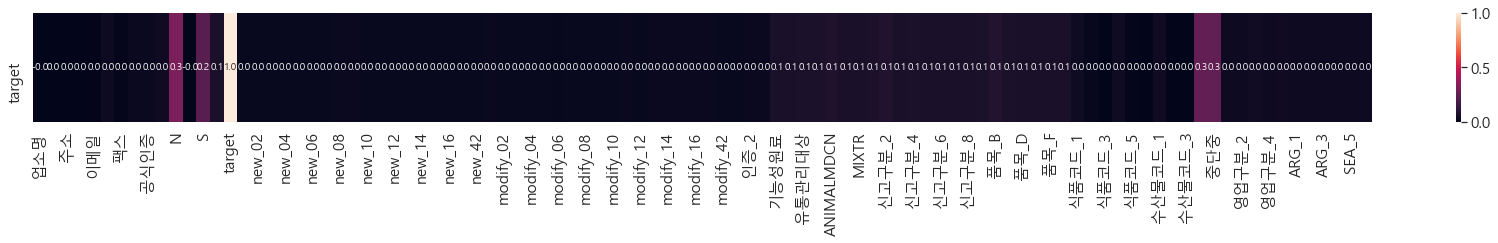

In [109]:
columns = df.columns
theilu = pd.DataFrame(index=['target'], columns= columns)

theilu = cat_corr(df)

<AxesSubplot:>

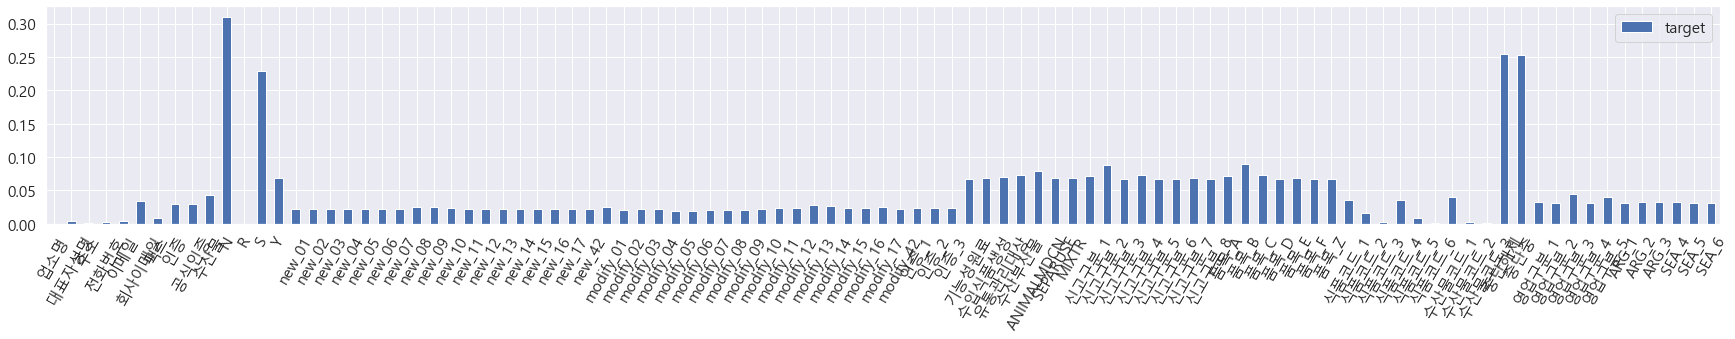

In [119]:
theilu.drop('target', axis=1).T.plot(kind='bar', rot='60', figsize=(30,4))

## CALIBRATION CURVE

  0%|          | 0/3 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

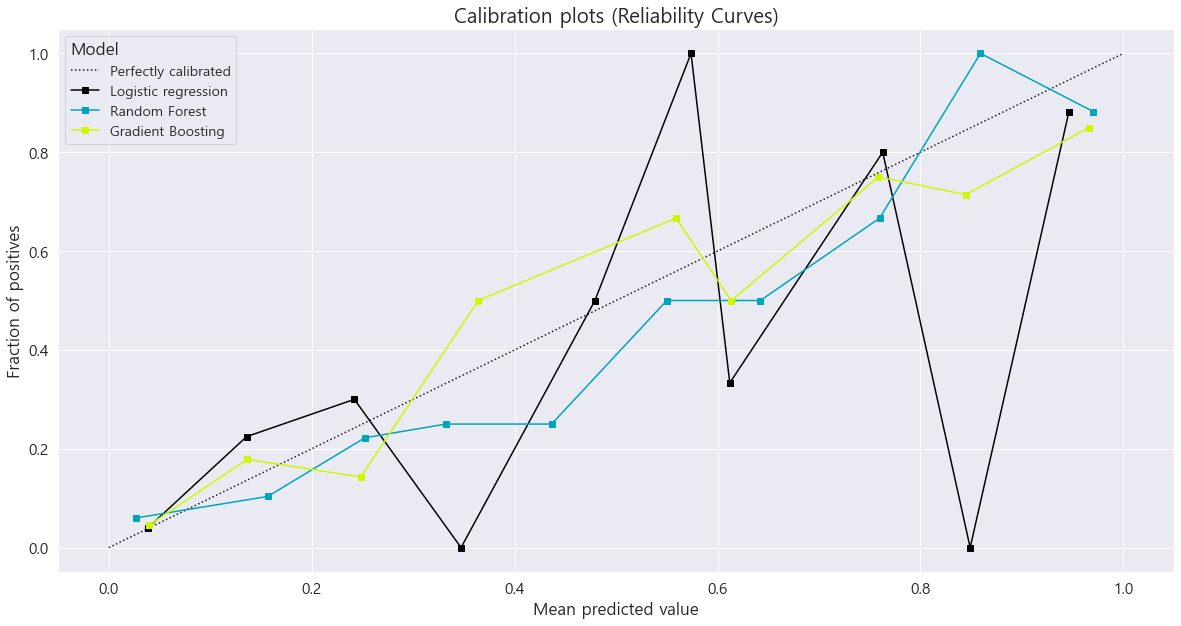

In [122]:
from tqdm import tqdm_notebook
import scikitplot as skplt

classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    y_proba = classifier.fit(X_train, y_train).predict_proba(X_val)
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_val, probas_list, classifier_labels, figsize=(20,10))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

## 테스트데이터(X_test)에 적용하여 결과 확인 : BMT

In [123]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report

import glob
glob.glob(path + '/*.*job*')

['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Gradient Boosting.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Logistic regression.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Random Forest.joblib']

### 최적 모델 불러오기

In [124]:
rf = load(glob.glob(path + '/*.*job*')[2])
rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', 'new_01', 'new_02', 'new_03', 'new_04', 'new_05',
       'new_06', 'new_07', 'ne...
       '식품코드_2', '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2',
       '수산물코드_3', '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4',
       '영업구분_5', 'ARG_1', 'ARG_2', 'ARG_3', 'SEA_4', 'SEA_5', 'SEA_6'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        max_features='auto',
                                        min_samples_leaf=0.01,
                                        min_samples_split=0.01, n_jobs=-1))])

In [125]:
rf.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', 'new_01', 'new_02', 'new_03', 'new_04', 'new_05',
       'new_06', 'new_07', 'ne...
       '식품코드_2', '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2',
       '수산물코드_3', '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4',
       '영업구분_

0.8757396449704142

              precision    recall  f1-score   support

       False       0.94      0.90      0.92       282
        True       0.60      0.73      0.66        56

    accuracy                           0.88       338
   macro avg       0.77      0.82      0.79       338
weighted avg       0.89      0.88      0.88       338



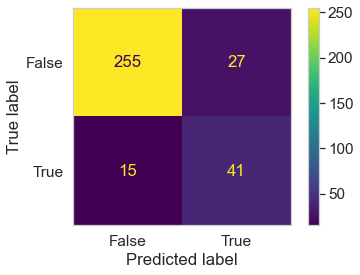

In [126]:
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

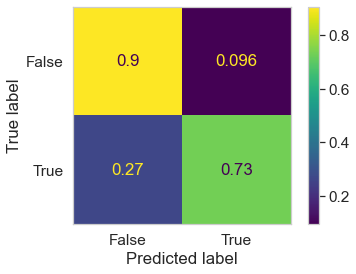

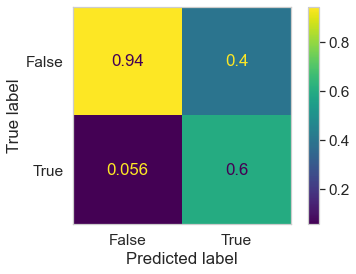

In [127]:
plot_confusion_matrix(rf, X_test, y_test, normalize='true')
plot_confusion_matrix(rf, X_test, y_test, normalize='pred')

## Decile 별로 부적합건수
- '1'은 부적합판정이 높은 percentile

array([[<AxesSubplot:title={'center':'probability_y'}>]], dtype=object)

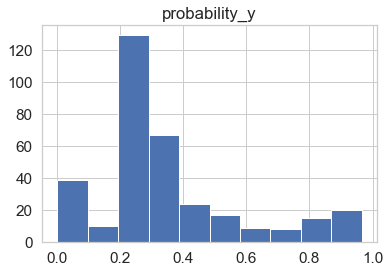

In [128]:
y_proba = rf.fit(X_train, y_train).predict_proba(X_test)
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf.hist()

Counter({False: 232, True: 39})

Text(0.5, 1.0, 'Distribution of probability of positive')

Text(0.5, 0, 'probability of positive')

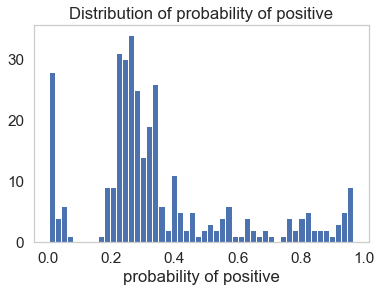

In [129]:
from collections import Counter
Counter(y_pred)
ax = plt.hist(y_proba[:, 1], bins=50)
plt.title('Distribution of probability of positive'); plt.xlabel('probability of positive')

In [130]:
tf['probability_y'].value_counts()

0.005394    16
0.343518    11
0.346141     7
0.393656     6
0.007384     6
            ..
0.322449     1
0.321289     1
0.321285     1
0.320051     1
0.002865     1
Name: probability_y, Length: 275, dtype: int64

<Figure size 720x360 with 0 Axes>

<AxesSubplot:xlabel='decile', ylabel='actual_y'>

Text(0.5, 1.0, 'Profit brought by each product decile')

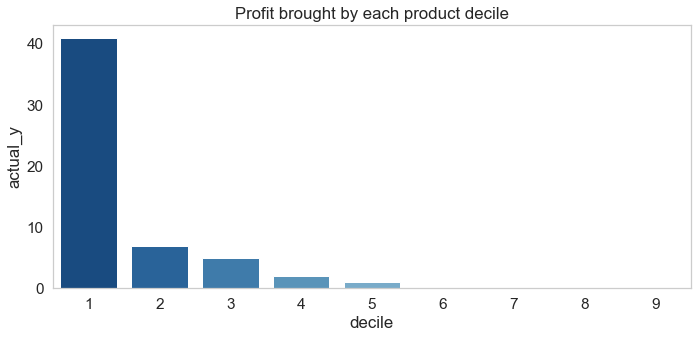

In [131]:
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf['decile'] = pd.qcut(tf["probability_y"], q = 5, labels = list(range(5, 0, -1)))

data = tf[['actual_y', 'decile']].groupby("decile").sum().reset_index().sort_values('decile', ascending=False)
plt.figure(figsize = (10,5))
sns.barplot(x = 'decile', y = 'actual_y', data = data, order = range(1, 10), palette = 'Blues_r')
plt.title("Profit brought by each product decile")
plt.tight_layout()

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

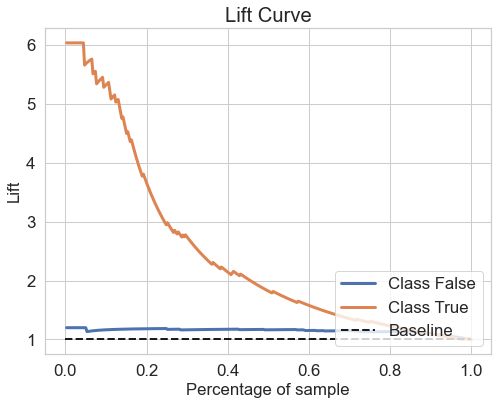

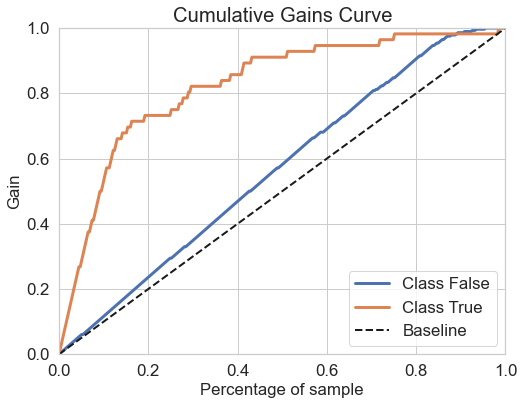

In [132]:
plt.rcParams["figure.figsize"] = (8,6)
y_proba = rf.predict_proba(X_test)
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

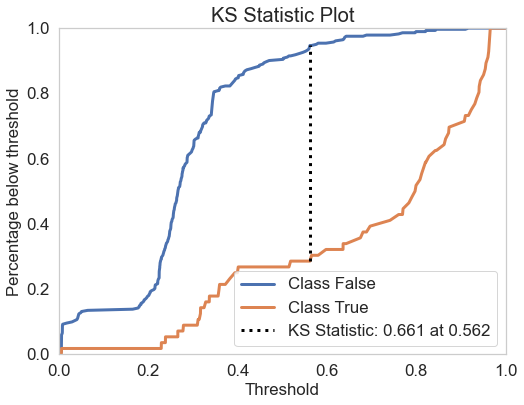

In [133]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

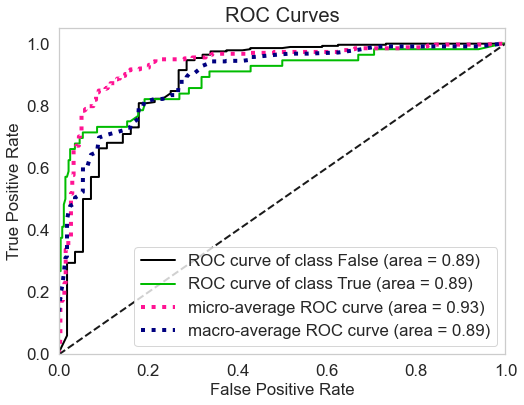

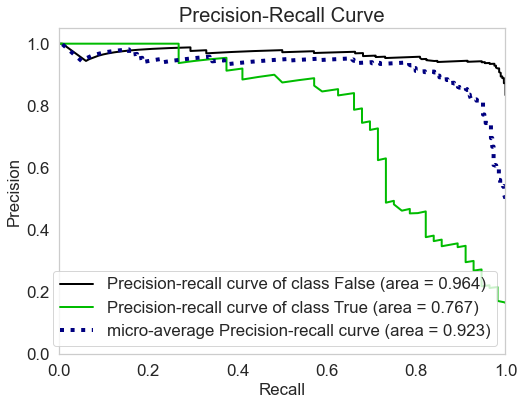

In [134]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [135]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

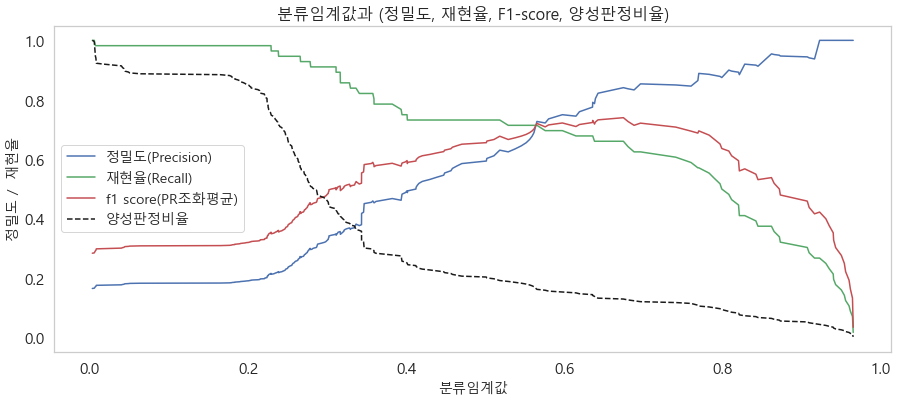

In [136]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

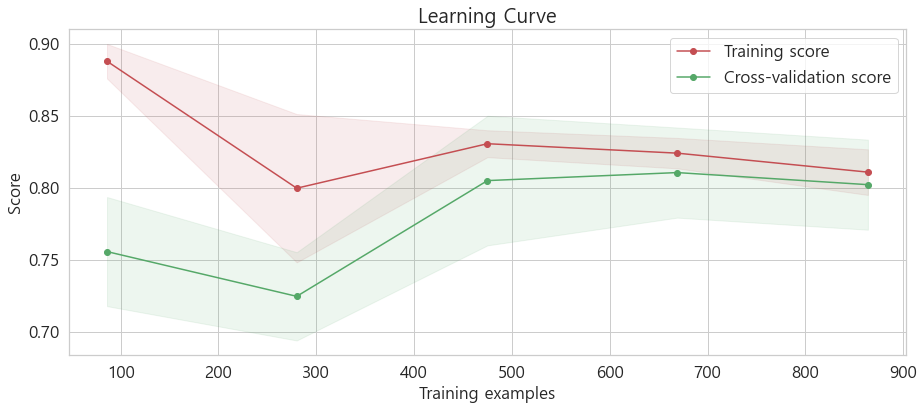

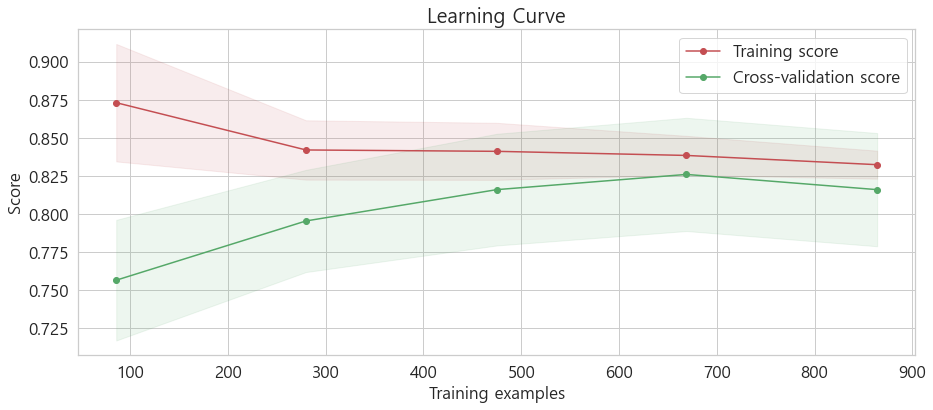

In [137]:
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='precision_macro')
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='recall_macro')

(array([ 39.,  10., 129.,  67.,  24.,  17.,   9.,   8.,  15.,  20.]),
 array([0.00286455, 0.09915695, 0.19544935, 0.29174175, 0.38803415,
        0.48432655, 0.58061894, 0.67691134, 0.77320374, 0.86949614,
        0.96578854]),
 <BarContainer object of 10 artists>)

(array([ 20.,  15.,   8.,   9.,  17.,  24.,  67., 129.,  10.,  39.]),
 array([0.03421146, 0.13050386, 0.22679626, 0.32308866, 0.41938106,
        0.51567345, 0.61196585, 0.70825825, 0.80455065, 0.90084305,
        0.99713545]),
 <BarContainer object of 10 artists>)

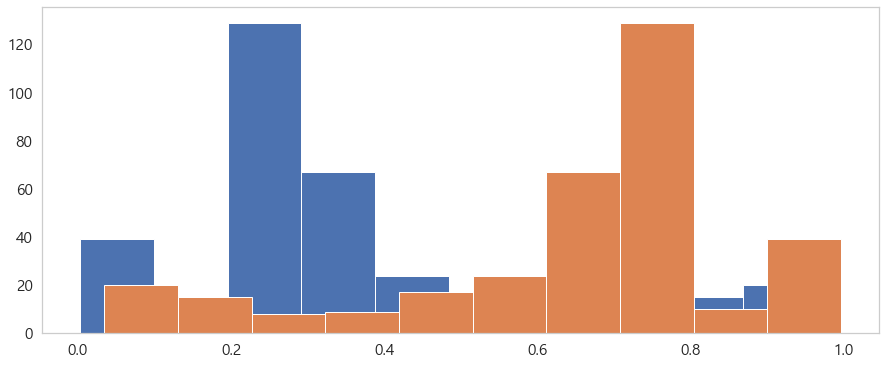

In [138]:
plt.hist(y_proba[:, 1]) 
plt.hist(y_proba[:, 0]) 

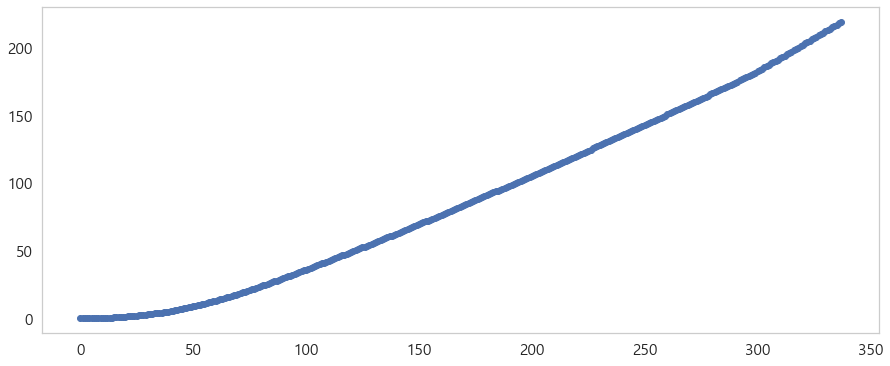

In [139]:
plt.scatter(np.arange(len(y_proba[:, 0])), np.sort(y_proba[:, 0]).cumsum()) 

In [140]:
from sklearn.metrics import balanced_accuracy_score, recall_score, precision_score

acc_list = []
recall_list = []
precision_list= []

for i in np.random.choice(2500, 300, replace=False) :
    clf = ensemble.RandomForestClassifier(n_estimators = 30, random_state = i) 
    preds =  clf.fit(X_train, y_train).predict(X_val) 
    
    bal_acc = round(balanced_accuracy_score(y_true = y_val, y_pred = preds), 3)
    recall = round(recall_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    precision = round(precision_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    
    acc_list.append(bal_acc)
    recall_list.append(recall)
    precision_list.append(precision)

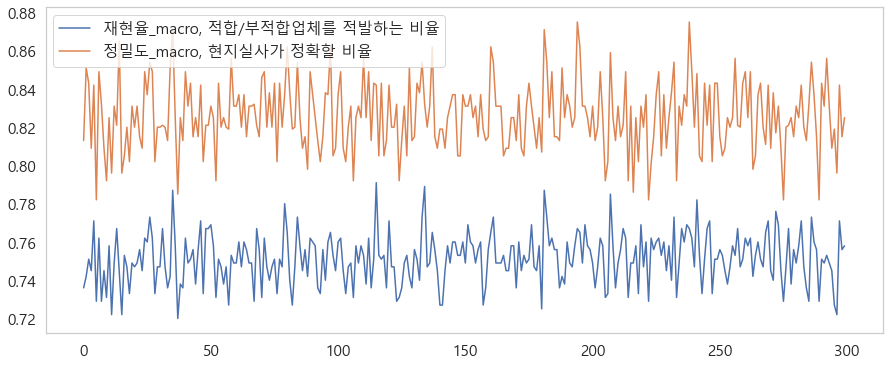

In [141]:
plt.plot(recall_list, label='재현율_macro, 적합/부적합업체를 적발하는 비율')
plt.plot(precision_list, label='정밀도_macro, 현지실사가 정확할 비율')
plt.legend()

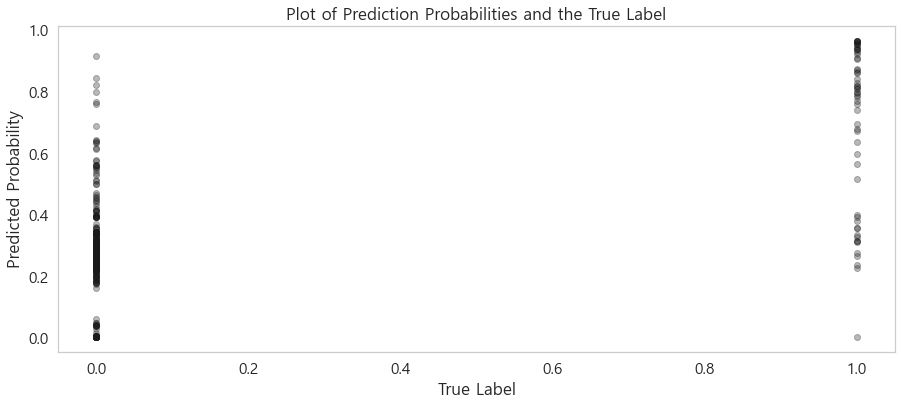

In [142]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])

ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.3},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

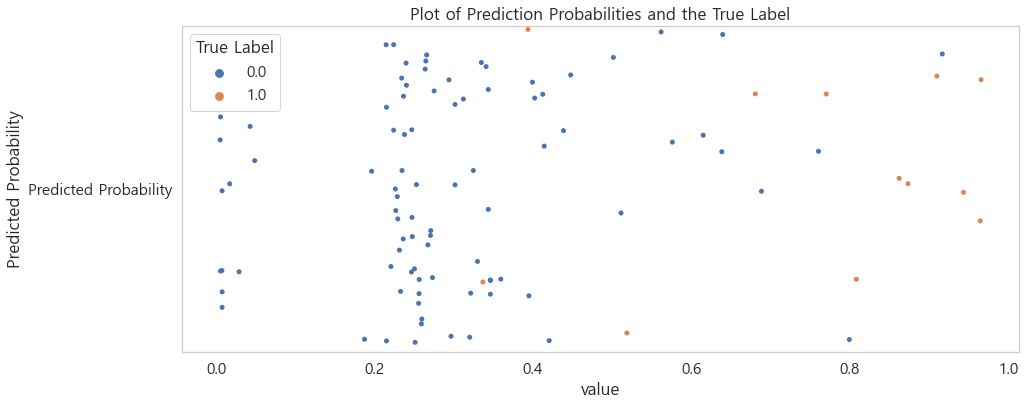

In [143]:
datamelted = pd.melt(data, "True Label", var_name="Predicted Probability")
ax = sns.stripplot(x="value", y="Predicted Probability",
                   hue='True Label', jitter=0.5, 
                   data=datamelted.sample(100, random_state=13)).set_title('Plot of Prediction Probabilities and the True Label')

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)

<Figure size 1800x360 with 0 Axes>

Text(0, 0.5, 'Features Importance')

Text(0.5, 1.0, '변수 중요도')

([<matplotlib.axis.XTick at 0x1b9b5a88fa0>,
 [Text(0, 0, '업소명'),
  Text(1, 0, '대표자성명'),
  Text(2, 0, '주소'),
  Text(3, 0, '전화번호'),
  Text(4, 0, '이메일'),
  Text(5, 0, '회사이메일'),
  Text(6, 0, '팩스'),
  Text(7, 0, '인증'),
  Text(8, 0, '공식인증'),
  Text(9, 0, '수산물'),
  Text(10, 0, 'N'),
  Text(11, 0, 'R'),
  Text(12, 0, 'S'),
  Text(13, 0, 'Y'),
  Text(14, 0, 'new_01'),
  Text(15, 0, 'new_02'),
  Text(16, 0, 'new_03'),
  Text(17, 0, 'new_04'),
  Text(18, 0, 'new_05'),
  Text(19, 0, 'new_06'),
  Text(20, 0, 'new_07'),
  Text(21, 0, 'new_08'),
  Text(22, 0, 'new_09'),
  Text(23, 0, 'new_10'),
  Text(24, 0, 'new_11'),
  Text(25, 0, 'new_12'),
  Text(26, 0, 'new_13'),
  Text(27, 0, 'new_14'),
  Text(28, 0, 'new_15'),
  Text(29, 0, 'new_16'),
  Text(30, 0, 'new_17'),
  Text(31, 0, 'new_42'),
  Text(32, 0, 'modify_01'),
  Text(33, 0, 'modify_02'),
  Text(34, 0, 'modify_03'),
  Text(35, 0, 'modify_04'),
  Text(36, 0, 'modify_05'),
  Text(37, 0, 'modify_06'),
  Text(38, 0, 'modify_07'),
  Text(39, 0, 'mo

<BarContainer object of 97 artists>

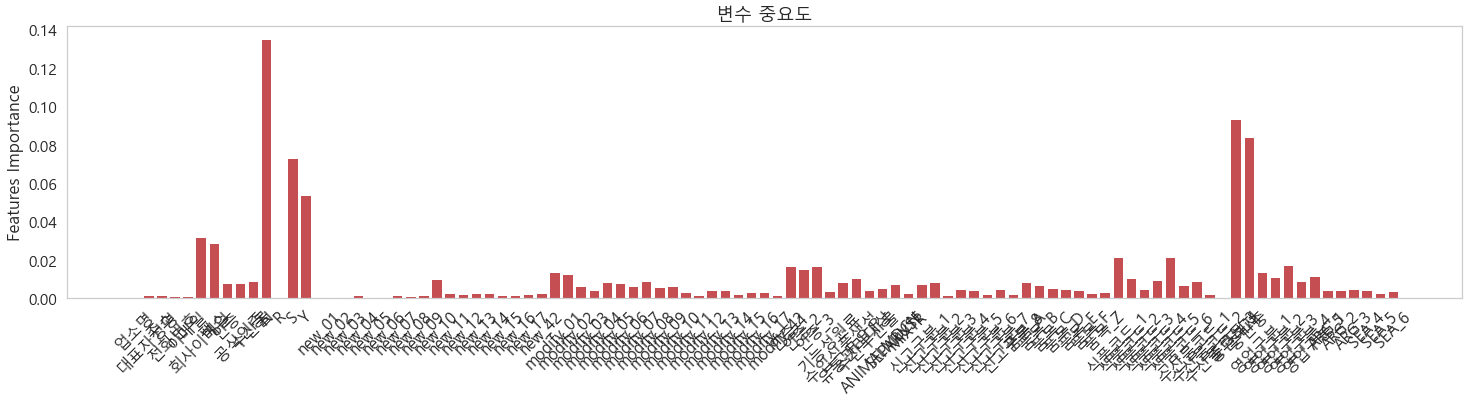

In [144]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, 
                                                  stratify= y, random_state=11)
dt = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
dt.fit(X, y)
plt.figure(figsize=(25,5)); plt.ylabel('Features Importance')
plt.title('변수 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), dt.feature_importances_, color='r')

## 로지스틱회귀모형으로 해석

In [145]:
model = LogisticRegression(solver='saga', random_state=11)
params = {'C': np.logspace(-4, 4, 20), 'penalty': ['l1', 'l2']}
grid = RandomizedSearchCV(model, param_distributions=params, cv=kf,
                          scoring = 'recall')
grid.fit(X_train, y_train)
print('optimal train score: {:.3f}'.format(grid.best_score_))
print('test score: {:.3f}'.format(grid.score(X_test, y_test)))
print('optimal parameter: {}'.format(grid.best_params_))

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(random_state=11, solver='saga'),
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2']},
                   scoring='recall')

optimal train score: 0.568
test score: 0.643
optimal parameter: {'penalty': 'l2', 'C': 1.623776739188721}


In [146]:
model= LogisticRegression(random_state=11, solver='saga').set_params(**grid.best_params_)
model.fit(X_train, y_train)

LogisticRegression(C=1.623776739188721, random_state=11, solver='saga')

In [147]:
model.intercept_
model.coef_

array([-0.21834757])

array([[-2.05430406e-01, -9.72959128e-02, -2.14765086e-01,
        -7.12549972e-02, -7.53708022e-02, -7.69441663e-01,
        -1.37019285e-01, -2.84048742e-01, -2.08053038e-01,
        -1.73471282e-01, -1.60019144e+00,  0.00000000e+00,
         6.10535935e-01,  7.84225103e-01,  2.97271258e-02,
         2.97271258e-02,  2.58871685e-02,  1.09463005e-01,
         2.97271258e-02,  2.97271258e-02,  1.00247827e-01,
        -9.18412346e-02, -1.13452800e-01, -1.70551946e-02,
         1.00029226e-01, -4.42731499e-02,  5.80467577e-02,
         4.61493868e-02,  5.47493823e-02,  6.96792152e-02,
         6.96792152e-02,  1.01241827e-01, -8.03542539e-02,
         9.25876510e-02, -1.57363188e-01,  7.69486504e-02,
         6.28387963e-02, -2.64468944e-01,  8.30166995e-03,
         9.63514972e-02, -2.17781648e-01, -7.73814439e-02,
         1.00925893e-01,  5.66275452e-02, -1.62512083e-01,
        -1.73766438e-01,  2.64859156e-02,  6.71572450e-02,
        -1.02566507e-01, -1.63219476e-02,  1.40529912e-0

<AxesSubplot:xlabel='variable'>

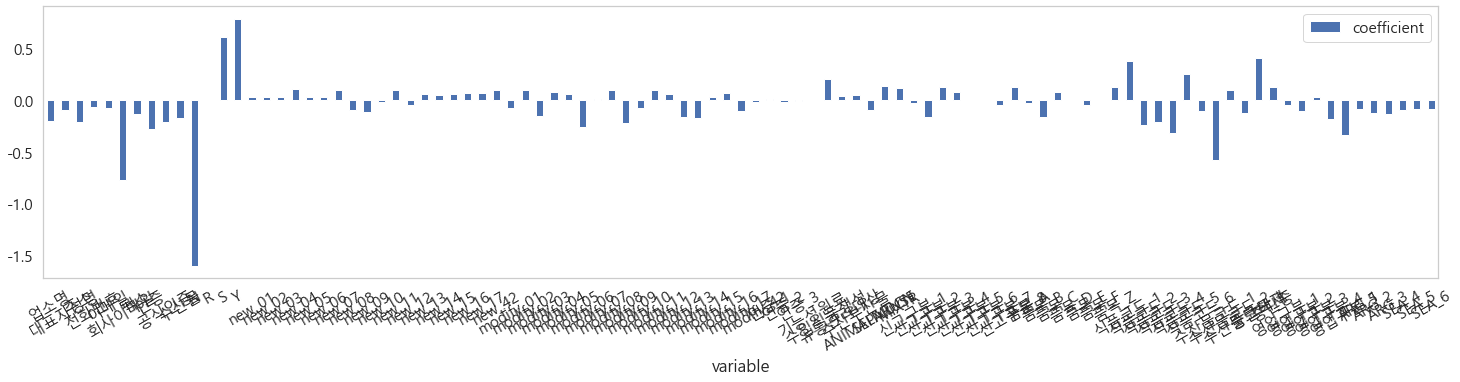

In [148]:
data = zip(X_train.columns, np.squeeze(model.coef_))
(pd.DataFrame(data, columns =['variable', 'coefficient']).set_index('variable').
plot.bar(rot='30', figsize=(25,5)))

## 선형모델(Logistic Regression) Interpretability, Explainability
- 검증데이터 첫번쨰를 예측해보고 설명해보자

In [149]:
from math import e
e
model.intercept_, model.coef_

2.718281828459045

(array([-0.21834757]),
 array([[-2.05430406e-01, -9.72959128e-02, -2.14765086e-01,
         -7.12549972e-02, -7.53708022e-02, -7.69441663e-01,
         -1.37019285e-01, -2.84048742e-01, -2.08053038e-01,
         -1.73471282e-01, -1.60019144e+00,  0.00000000e+00,
          6.10535935e-01,  7.84225103e-01,  2.97271258e-02,
          2.97271258e-02,  2.58871685e-02,  1.09463005e-01,
          2.97271258e-02,  2.97271258e-02,  1.00247827e-01,
         -9.18412346e-02, -1.13452800e-01, -1.70551946e-02,
          1.00029226e-01, -4.42731499e-02,  5.80467577e-02,
          4.61493868e-02,  5.47493823e-02,  6.96792152e-02,
          6.96792152e-02,  1.01241827e-01, -8.03542539e-02,
          9.25876510e-02, -1.57363188e-01,  7.69486504e-02,
          6.28387963e-02, -2.64468944e-01,  8.30166995e-03,
          9.63514972e-02, -2.17781648e-01, -7.73814439e-02,
          1.00925893e-01,  5.66275452e-02, -1.62512083e-01,
         -1.73766438e-01,  2.64859156e-02,  6.71572450e-02,
         -1.02566

In [150]:
X_test.head(2)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
PH000000085,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ID000006157,True,True,True,True,True,False,True,False,False,True,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [151]:
model.coef_ * X_test.iloc[0].values
minus_beta_X = np.sum(model.coef_ * X_test.iloc[0].values)

array([[-0.20543040634518078, -0.09729591282590375, -0.2147650863958259,
        -0.07125499722860919, -0.07537080217815918, -0.7694416628340305,
        -0.1370192847618616, -0.0, -0.0, -0.0, -1.6001914445366208, 0.0,
        0.0, 0.0, 0.05945425169488743, 0.05945425169488743,
        0.051774336981282046, 0.21892600992207817, 0.05945425169488743,
        0.05945425169488743, 0.20049565317838614, -0.1836824692253729,
        -0.22690559940989954, -0.03411038920282874, 0.2000584520902976,
        -0.08854629980917134, 0.11609351544865482, 0.09229877351119886,
        0.10949876452584566, 0.13935843040865287, 0.13935843040865287,
        0.2024836542360928, -0.16070850778404927, 0.1851753019875472,
        -0.31472637610904086, 0.1538973007077412, 0.1256775925043701,
        -0.5289378886474544, 0.016603339897578874, 0.19270299447177222,
        -0.4355632964684491, -0.15476288785500145, 0.2018517856560421,
        0.11325509039123811, -0.32502416548347335, -0.34753287693208323,
       

In [152]:
1/(1+e**(minus_beta_X ))

0.9664102638309433

In [153]:
1/(1+e**0)
1/(1+e**100)
1/(1+e**-100)

0.5

3.7200759760208555e-44

1.0

# Approaches: Statistics vs. Machine Learning
<img src='https://miro.medium.com/max/875/1*k_3rh-3zr_ebX06vFSkZHw.png'>
<img src = 'https://miro.medium.com/max/875/1*eJYDfncrjRfXXZn2b2MSbQ.png'>

# SHAP
## model agnostic interpretability (eXAI)
## SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model
https://github.com/slundberg/shap

<img src='https://raw.githubusercontent.com/slundberg/shap/master/docs/artwork/shap_header.svg' width=600 height=400>

In [154]:
import xgboost
import shap
# train an XGBoost model
#X, y =shap.datasets.adult()
X.head(10)
y[0:10]

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000995,True,True,True,True,True,True,True,True,True,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ID000001276,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000001815,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000002079,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


해외제조업소_코드
CN000095375    False
CN000010833    False
VN000000420    False
JP000002818    False
TH000001271    False
VN000000995    False
ID000001276     True
US000001815    False
VN000002079    False
TH000000292    False
Name: target, dtype: bool

In [155]:
model = xgboost.XGBClassifier(eval_metric='mlogloss').fit(X, y)
explainer = shap.Explainer(model) # explainer = shap.Explainer(model, X)
shap_values = explainer(X)
shap_values[0]
shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[6])

ValueError: DataFrame.dtypes for data must be int, float, bool or category.  When
categorical type is supplied, DMatrix parameter `enable_categorical` must
be set to `True`. Invalid columns:업소명, 대표자성명, 주소, 전화번호, 이메일, 회사이메일, 팩스, 인증, 공식인증, 수산물, N, R, S, Y, new_01, new_02, new_03, new_04, new_05, new_06, new_07, new_08, new_09, new_10, new_11, new_12, new_13, new_14, new_15, new_16, new_17, new_42, modify_01, modify_02, modify_03, modify_04, modify_05, modify_06, modify_07, modify_08, modify_09, modify_10, modify_11, modify_12, modify_13, modify_14, modify_15, modify_16, modify_17, modify_42, 인증_1, 인증_2, 인증_3, 기능성원료, 수입식품생성, 유통관리대상, 수산부산물, ANIMALMDCN, SEPARUSE, MIXTR, 신고구분_1, 신고구분_2, 신고구분_3, 신고구분_4, 신고구분_5, 신고구분_6, 신고구분_7, 신고구분_8, 품목_A, 품목_B, 품목_C, 품목_D, 품목_E, 품목_F, 품목_Z, 식품코드_1, 식품코드_2, 식품코드_3, 식품코드_4, 식품코드_5, 식품코드_6, 수산물코드_1, 수산물코드_2, 수산물코드_3, 중단해제, 중단중, 영업구분_1, 영업구분_2, 영업구분_3, 영업구분_4, 영업구분_5, ARG_1, ARG_2, ARG_3, SEA_4, SEA_5, SEA_6

In [156]:
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(X)
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values[0])
shap.plots.force(explainer.expected_value, shap_values[6])

Exception: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'>

In [79]:
shap_values
print(f'\n\n원자료의 크기{X.shape}와 SHAP value의 크기{shap_values.shape}')

array([[ 0.02356417,  0.0148988 ,  0.        , ..., -0.5529252 ,
        -0.08078138, -0.0308699 ],
       [ 0.02356417,  0.0148988 ,  0.        , ..., -0.5529252 ,
        -0.08078138, -0.0308699 ],
       [ 1.2615113 ,  0.0148367 ,  0.        , ..., -0.60907835,
        -0.12659927,  0.01039654],
       ...,
       [-0.04296684,  0.0169965 ,  0.        , ..., -0.87131906,
        -0.14322402,  0.01048211],
       [ 1.0425425 ,  0.01487372,  0.        , ..., -0.7318908 ,
        -0.13757126, -0.00211327],
       [ 1.0425425 ,  0.01487372,  0.        , ..., -0.7318908 ,
        -0.13757126, -0.00211327]], dtype=float32)



원자료의 크기(1689, 13)와 SHAP value의 크기(1689, 13)


In [80]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['sum of SHAP'] = data.sum(1)  # 특성 변수의 SHAP values
data['average mean of model prediction'] = np.mean(model.predict(X))
data['prediction value by shap'] = data['sum of SHAP'] + data['average mean of model prediction']
#data['prediction by model'] = model.predict(X)
data['prediction by model'] = model.predict(X)

In [81]:
data.head(10)
shap_values[0]
shap_values[6]

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,sum of SHAP,average mean of model prediction,prediction value by shap,prediction by model
0,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,0.123742,0.685161,False
1,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,0.123742,0.685161,False
2,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,0.123742,0.666192,False
3,0.585718,0.017044,0.0,0.027914,0.014736,-0.739285,0.221285,0.127990,-0.146016,0.136975,-0.846611,-0.146402,-0.012618,-0.759267,0.123742,-0.635526,False
4,-1.110362,0.101956,0.0,0.028917,0.013844,-0.227823,0.346178,-0.375246,-0.224441,0.301570,2.637660,-0.631118,-0.096579,0.764558,0.123742,0.888300,False
5,0.515115,0.013862,0.0,0.023515,0.007797,-0.362927,0.001776,-0.213104,-0.150873,0.282640,-0.635336,-0.137353,0.008628,-0.646259,0.123742,-0.522517,False
6,0.489279,0.116791,0.0,0.025635,0.010510,0.211129,0.022459,-0.019946,0.005031,0.518182,3.924726,1.642316,0.011227,6.957340,0.123742,7.081082,True
7,0.250316,0.018135,0.0,0.029180,0.014811,-0.158309,0.170004,0.216376,-0.011563,0.171818,-0.905716,-0.142065,0.019977,-0.327036,0.123742,-0.203294,False
8,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,0.123742,0.666192,False
9,-0.484401,0.013681,0.0,0.030063,0.012861,-0.161747,0.133142,-0.104062,0.107809,0.234924,-0.719495,-0.146510,0.008029,-1.075706,0.123742,-0.951964,False


array([ 0.02356417,  0.0148988 ,  0.        ,  0.02944477,  0.01568345,
        0.5950321 ,  0.04651415, -0.0448022 ,  0.18699121,  0.35866883,
       -0.5529252 , -0.08078138, -0.0308699 ], dtype=float32)

array([ 0.4892791 ,  0.11679139,  0.        ,  0.02563503,  0.01051034,
        0.21112876,  0.02245855, -0.0199459 ,  0.00503143,  0.51818246,
        3.9247265 ,  1.642316  ,  0.01122656], dtype=float32)

In [82]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['SUM'] = data.sum(1)  # 특성 변수의 SHAP values
data['f(x)'] = model.predict(X)
data['E[f(x)]'] = np.mean(model.predict(X))
data['SUM + E[f(x)]'] = data['SUM'] + data['E[f(x)]']
data.head(10)

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,SUM,f(x),E[f(x)],SUM + E[f(x)]
0,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,False,0.123742,0.685161
1,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,False,0.123742,0.685161
2,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,False,0.123742,0.666192
3,0.585718,0.017044,0.0,0.027914,0.014736,-0.739285,0.221285,0.127990,-0.146016,0.136975,-0.846611,-0.146402,-0.012618,-0.759267,False,0.123742,-0.635526
4,-1.110362,0.101956,0.0,0.028917,0.013844,-0.227823,0.346178,-0.375246,-0.224441,0.301570,2.637660,-0.631118,-0.096579,0.764558,False,0.123742,0.888300
5,0.515115,0.013862,0.0,0.023515,0.007797,-0.362927,0.001776,-0.213104,-0.150873,0.282640,-0.635336,-0.137353,0.008628,-0.646259,False,0.123742,-0.522517
6,0.489279,0.116791,0.0,0.025635,0.010510,0.211129,0.022459,-0.019946,0.005031,0.518182,3.924726,1.642316,0.011227,6.957340,True,0.123742,7.081082
7,0.250316,0.018135,0.0,0.029180,0.014811,-0.158309,0.170004,0.216376,-0.011563,0.171818,-0.905716,-0.142065,0.019977,-0.327036,False,0.123742,-0.203294
8,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,False,0.123742,0.666192
9,-0.484401,0.013681,0.0,0.030063,0.012861,-0.161747,0.133142,-0.104062,0.107809,0.234924,-0.719495,-0.146510,0.008029,-1.075706,False,0.123742,-0.951964


In [83]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values)

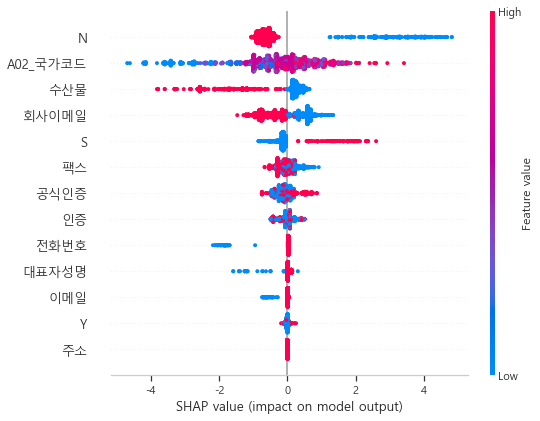

In [84]:
shap.summary_plot(shap_values, X)

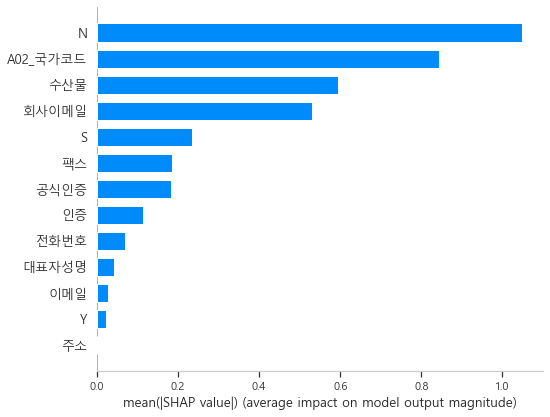

In [85]:
shap.summary_plot(shap_values, X, plot_type="bar")

# 향후 계획(2023년도)

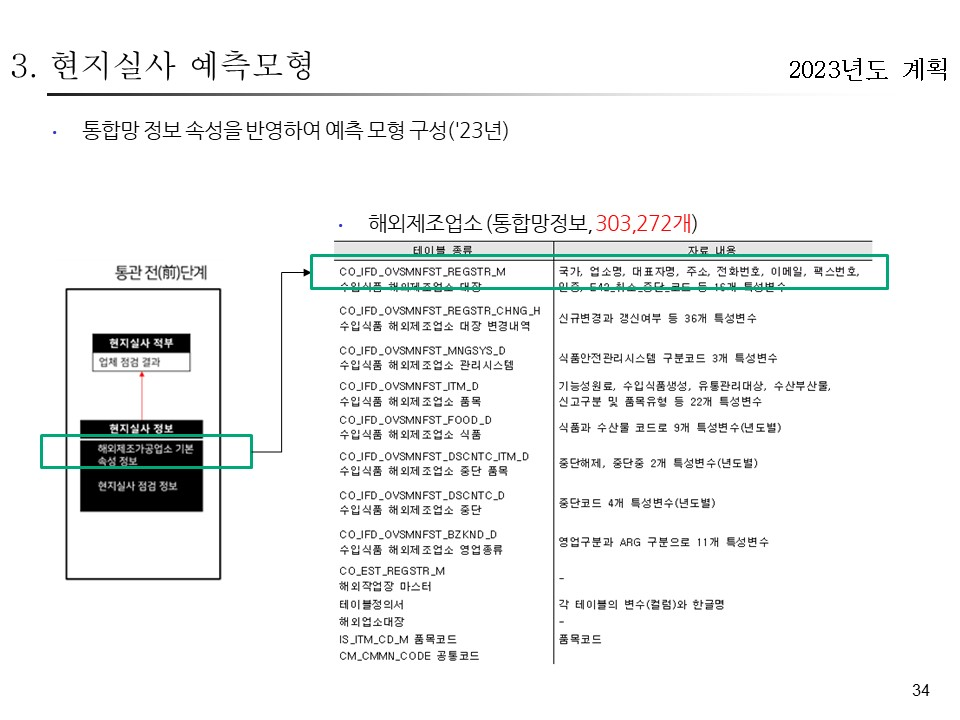

In [86]:
Image(filename= img_path + '/슬라이드34.JPG', width=width, height=height)

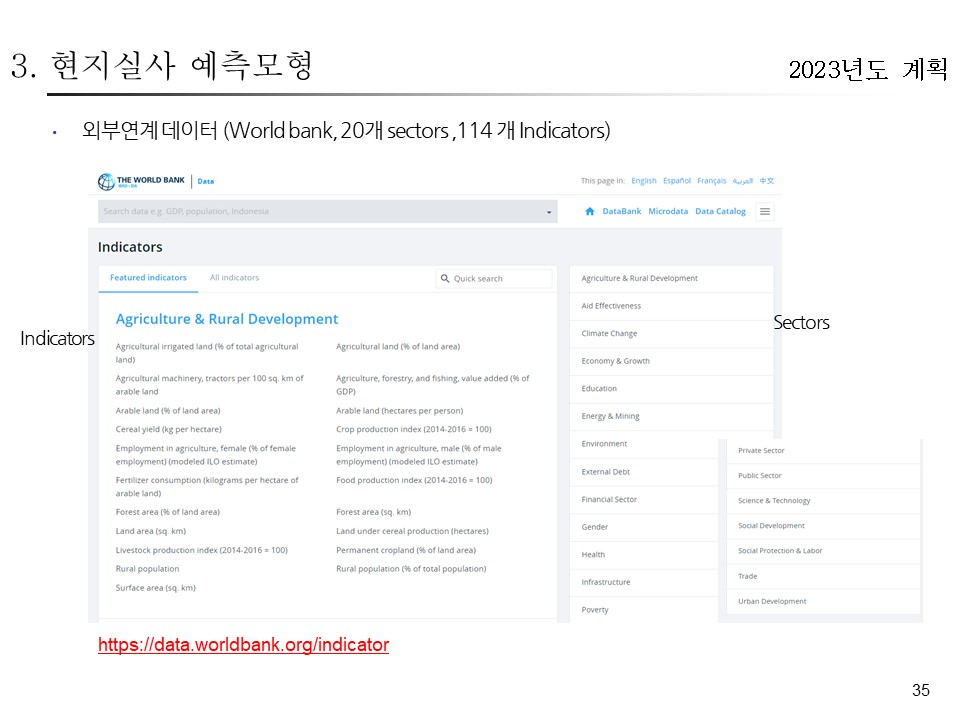

In [87]:
Image(filename= img_path + '/슬라이드35.JPG', width=width, height=height)

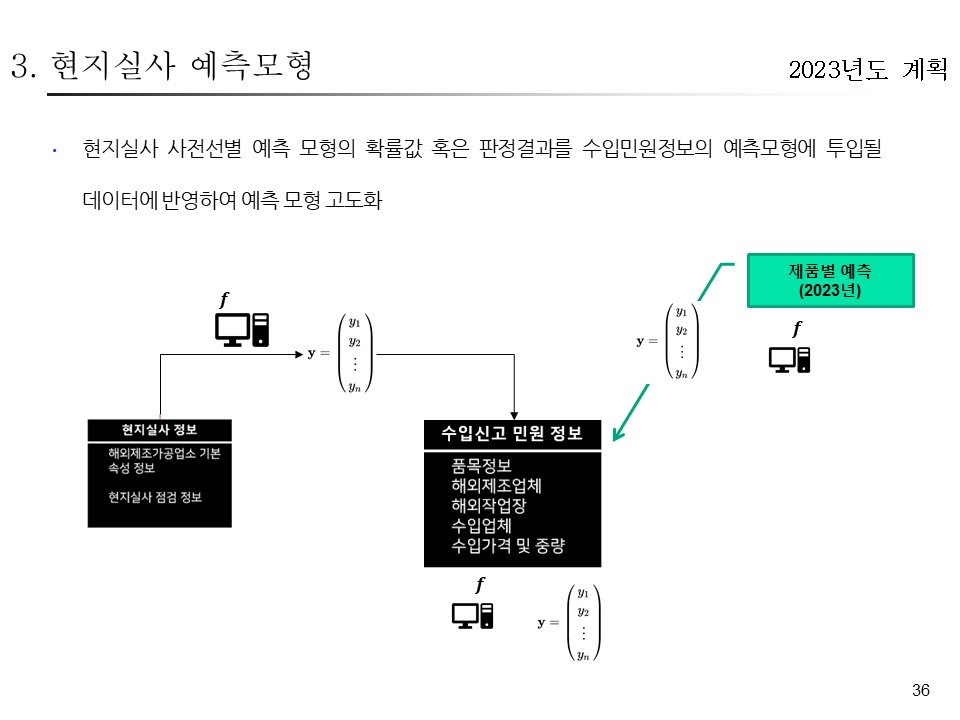

In [88]:
Image(filename= img_path + '/슬라이드36.JPG', width=width, height=height)

# Pycaret

In [2]:
# https://pycaret.gitbook.io/docs/#classification
# 준비
from pycaret.classification import *
import pandas as pd

In [29]:
data = pd.read_pickle('../working_ml/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


In [30]:
# data.drop(['업소명','R','N','S'], axis=1, inplace=True)
data.drop(['업소명','R'], axis=1, inplace=True)

In [31]:
data.corr().shape

(13, 13)

In [32]:
train = data.sample(frac=0.8)
test = data[~data.index.isin(train.index)]

In [33]:
train.shape, test.shape

((1351, 13), (338, 13))

In [34]:
clf1 = setup(data = train, target = 'target', silent=True, fix_imbalance=True)

,Description,Value
0,session_id,344
1,Target,target
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(1351, 13)"
5,Missing Values,False
6,Numeric Features,0
7,Categorical Features,12
8,Ordinal Features,False
9,High Cardinality Features,False


In [35]:
# model training and selection
# best = compare_models()
# best = compare_models(include=['knn'])
best = compare_models(exclude=['knn','qda','dummy'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8931,0.0000,0.6239,0.7190,0.6595,0.5976,0.6047,0.0130
lda,Linear Discriminant Analysis,0.8931,0.8603,0.6239,0.7190,0.6595,0.5976,0.6047,0.0140
ada,Ada Boost Classifier,0.8856,0.8583,0.6474,0.6908,0.6570,0.5897,0.5971,0.0700
nb,Naive Bayes,0.8742,0.8581,0.6294,0.7031,0.6383,0.5670,0.5840,0.0140
lr,Logistic Regression,0.8739,0.8562,0.6665,0.6585,0.6426,0.5689,0.5818,0.0210
lightgbm,Light Gradient Boosting Machine,0.8634,0.8649,0.7107,0.6017,0.6403,0.5583,0.5693,0.0340
rf,Random Forest Classifier,0.8613,0.8614,0.7044,0.5997,0.6367,0.5535,0.5639,0.2540
xgboost,Extreme Gradient Boosting,0.8613,0.8629,0.6982,0.5961,0.6315,0.5483,0.5592,0.1760
gbc,Gradient Boosting Classifier,0.8602,0.8599,0.7169,0.5896,0.6379,0.5540,0.5646,0.0750
et,Extra Trees Classifier,0.8591,0.8609,0.7044,0.5935,0.6326,0.5481,0.5593,0.2180


In [36]:
# 모델 평가
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [37]:
interpret_model(best, plot = 'pfi')

12it [00:00, 73.51it/s]


In [13]:
# test set으로 예측
predictions = predict_model(best, data = test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9201,0.8422,0.6607,0.8222,0.7327,0.6864,0.6920


In [14]:
predictions

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,S,Y,target,Label,Score
11,True,True,True,True,False,True,False,False,False,True,False,True,True,1.0
13,True,True,True,True,True,False,True,True,False,False,False,False,False,1.0
19,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0
30,True,True,True,True,False,False,False,False,False,False,False,False,False,1.0
32,True,True,True,True,False,True,False,False,False,False,False,False,False,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,True,True,True,True,False,False,False,False,False,1.0
1670,True,True,True,True,True,False,False,False,False,False,False,True,False,1.0
1674,True,True,True,True,False,True,False,False,False,False,True,True,True,0.6
1679,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0


In [15]:
predictions['target'].value_counts()

False    282
True      56
Name: target, dtype: int64

In [16]:
# predictions['Label'].replace({'False':False,'True':True})

In [17]:
predictions.groupby('target').Label.value_counts().unstack()

Label,False,True
target,,
False,274,8
True,19,37


In [16]:
test

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,...,NV.IND.TOTL.ZS,NY.GDP.DEFL.KD.ZG,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,SL.EMP.TOTL.SP.ZS,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.URB.TOTL.IN.ZS,TG.VAL.TOTL.GD.ZS,target
3,True,True,True,True,False,True,False,False,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
5,True,True,True,True,False,False,True,True,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
9,True,True,True,True,True,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
21,True,True,True,True,False,False,False,False,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
26,True,True,True,True,False,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,False,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1661,True,True,True,True,True,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1665,True,True,True,True,False,False,False,False,False,True,...,21.688295,5.067760,3521.591948,-10.134432,38.179001,16.823999,76.891,69.568,77.279504,False
1684,True,True,True,True,True,True,False,False,True,True,...,32.004504,-0.923994,5600.389615,-9.158745,60.669998,6.427000,77.216,64.166,38.646664,False


In [17]:
best.predict_proba(test.iloc[:,:-1])

array([[0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.

In [18]:
(best.predict_proba(test.iloc[:,:-1])>0.99).mean(axis=0)

array([0., 0.])

<AxesSubplot:ylabel='Frequency'>

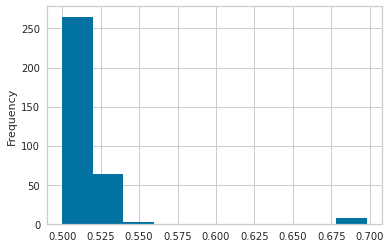

In [20]:
predictions['Score'].plot.hist()

In [21]:
# 결과 평가
(predictions['target']==predictions['Label'].replace({'False':False, 'True':True})).mean()

0.9023668639053254

In [22]:
predictions['Label'].replace({'False':False, 'True':True}).mean()

0.14792899408284024

# End